<h4><b>Asignatura:</b> Procesamiento Natural del Lenguaje.<br>
<b>Docente:</b> James Tomalá.<br>
<b>Institución:</b> IPP.<br>
<b>Fecha de Entrega:</b><br>
<b>Estudiante:</b> Jason Andrés Urrutia Orellana.</h4>

<h5><b>CONTEXTO:</b><em> La concesionaria AutoFlex, donde trabajamos como parte de una célula Data
Science, está preocupada por la aceptación de la nueva versión de su marca estrella.
Se han recibido muchos comentarios en redes sociales al respecto, y claramente se
quiere optimizar el costo de procesamiento de esas opiniones. Para ello, desea
interpretar esos comentarios utilizando el preprocesamiento de texto e implementar
un modelo para resumir las opiniones de manera automática. El equipo de trabajo
propone realizar un análisis de sentimientos que clasifique cada texto escrito, ya que
la gerencia comercial tiene un conjunto de comentarios clasificados como “bueno”,
“malo” o “info” (necesita más información). Debemos realizar, primero, una
descarga de la base, y terminar de sustentar metodológicamente el proyecto.</em></h5>

<h2><b>CONSIGNAS</b></h2>

<p><b>1A.</b><em> ¿Qué tipo de aplicación es un análisis de sentimientos?</em><br>
<b>Respuesta:</b> El análisis de sentimientos es una aplicación de las tecnologías de procesamiento del lenguaje natural (PLN) que entrena a un software informático para comprender textos de forma similar a como lo hacen los humanos.</p>

<p><b>1B.</b> ¿Qué tipo de procesamiento es necesario realizar primero? Exponga en un dibujo.<br>
<b>Respuesta:</b></p> <img src="dibujo.png" width="700">

<p><b>2.</b><em>La gerencia de marketing le ha entregado una tabla con diferentes comentarios de los
clientes, la cual se llama “comentarios.csv”. Primeramente, realice una lectura de los
datos. Para ello, use el método read_csv en vez de read_table; utilice como separador
la coma (,). Indique cuántos registros tiene la tabla y cuántas columnas; visualice los
20 primeros registros.</em></p>

In [1]:
# Librerías requeridas
import pandas as pd
import matplotlib.pyplot as plt
import re
from nltk.tokenize import RegexpTokenizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
comentarios = pd.read_csv("comentarios.csv", sep=",")
print("Cantidad de registros:", comentarios.shape[0])
print("Cantidad de columnas:", comentarios.shape[1])

Cantidad de registros: 600
Cantidad de columnas: 3


In [3]:
comentarios.head(20)

,orden,comentario,tipo
0,1,"No les creo nada ,",malo
1,2,Está bonita la camioneta,bueno
2,3,Quiero más información,info
3,4,:( igual el crédito ha de ser muuuucho,malo
4,5,"Quisiera, más información, pero nadie me respo...",info
5,6,"cuota chica, pero digan la última cuota, de se...",malo
6,7,"Yo tengo uno claro la versión anterior ,,me ha...",bueno
7,8,"No lo compres, son fabricados en méxico",malo
8,9,"🥰❤❣💯, amo esta marca",bueno
9,10,más IVA? Ni que la weá la uses como camioneta,malo


<p><b>3.</b><em> Realice un análisis exploratorio de esta data encontrando el porcentaje de tipo de
comentarios que han sido clasificados como malos, buenos o información, aplique el
código Python que considere necesario y exprese el resultado en una tabla.</em></p>

In [4]:
cantidades = comentarios["tipo"].value_counts()
porcentaje = round(comentarios["tipo"].value_counts(normalize = True) * 100, 2)

In [5]:
tabla = pd.DataFrame({"Cantidad" : cantidades, "Porcentaje" : porcentaje})
tabla


,Cantidad,Porcentaje
tipo,,
malo,270,45.0
bueno,222,37.0
info,108,18.0


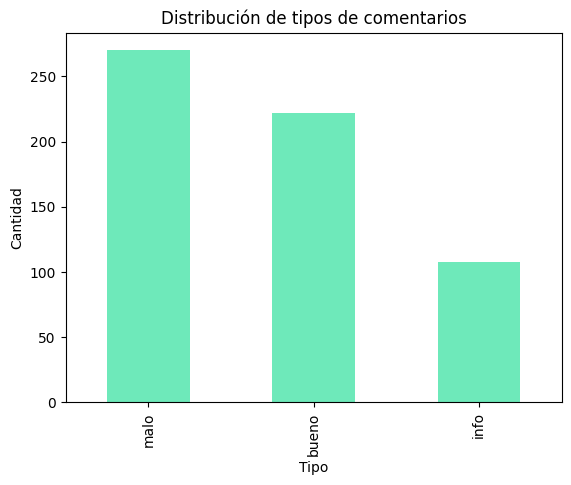

In [6]:
comentarios["tipo"].value_counts().plot(kind = "bar", color = "#6ee9ba")
plt.title("Distribución de tipos de comentarios")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.show()

<p><b>4.</b><em> Diseñe un patrón de expresión regular para utilizarlo como tokenizador más adelante,
que además de las palabras en idioma español, lea emojis. También
considere la expresión como “:)” como un solo token, pero que excluya la puntuación
punto “.”, coma “,” y punto y coma “;”.</em></p>

In [7]:
patron = RegexpTokenizer(r"(?![.,;])[A-Za-zÁÉÍÓÚáéíóúÑñ]+|:\(|:\)|[\U0001F300-\U0001FAFF]|[❤❣]")

<p><b>5.</b><em> Defina el conjunto X como los comentarios del data frame, y el target, y como la
columna tipo</em></p>

In [8]:
x = comentarios["comentario"].values
y = comentarios["tipo"].values

<h4><b>EXTRA</b></h4>

<p>Creación del modelo:</p>

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1, stratify = y)

In [10]:
vectorizador = CountVectorizer(tokenizer = patron.tokenize, token_pattern = None)

x_train_bagofwords = vectorizador.fit_transform(x_train)
x_test_bagofwords = vectorizador.transform(x_test)

In [11]:
modelo = MultinomialNB()
modelo.fit(x_train_bagofwords, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [12]:
predicciones = modelo.predict(x_test_bagofwords)

<p>Métricas:</p>

In [13]:
accuracy = accuracy_score(y_test, predicciones)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, predicciones)
print("Matriz de confusión:\n", cm)

Accuracy: 0.975
Matriz de confusión:
 [[41  0  3]
 [ 0 22  0]
 [ 0  0 54]]


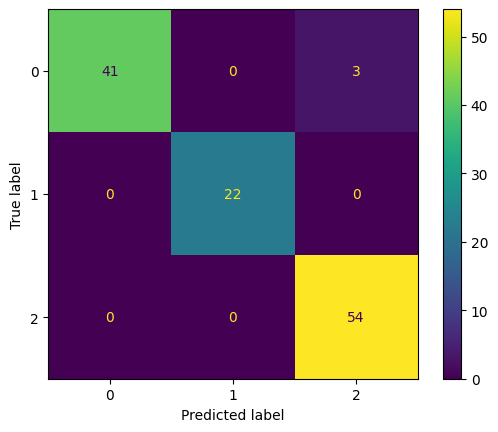

In [14]:
ConfusionMatrixDisplay(cm).plot()
plt.show()

<h4><b>Conclusión:</b></h4><p>En este trabajo se analizó comentarios de diversos clientes acerca de la aceptación de la nueva versión de la marca estrella de AutoFlex. Se realizó la lectura y exploración de 600 comentarios, se implementó una tokenización personalizada mediante expresiones regulares para reconocer palabras en español, emojis y emoticonos, ignorando comas(,), puntos(.) y punto y coma(;) integrándola posteriormente al proceso de vectorización y clasificación.

Posteriormente, los comentarios fueron transformados a una representación numérica mediante Bag of Words y se entrenó un modelo Multinomial Naive Bayes para clasificar automáticamente los comentarios en las categorías "bueno", "malo" e "info". Al evaluar el modelo, se obtuvo una exactitud (accuracy) del 97,5%, lo que significa que casi todos los comentarios del conjunto de prueba fueron clasificados correctamente. Además, la matriz de confusión mostró que hubo solamente 3 errores de clasificación</p>